# Laboratório 4 - Programação Concorrente (ICP-361)

**Gabriel P. Silva / Silvana Rossetto **  
**Instituto de Computação/UFRJ - 2026-1**

## Tópicos:
- Comunicação entre threads via memória compartilhada
- Corrida de dados e Violação de atomicidade
- Alocação dinâmica de tarefa para as threads

---

## Configuração Inicial

Como o Google Colab não suporta nativamente a compilação de código C com Pthreads, vamos configurar o ambiente:

In [ ]:
# Instalar o compilador GCC (já disponível no Colab)
!gcc --version

gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.



---
# Atividade 1: Corrida de Dados

**Objetivo:** Mostrar um exemplo simples de programa com uma variável compartilhada entre threads e o problema de corrida de dados.

### Código:
- Modifique o código para que a passagem de parâmetros para as *threads* seja feita de forma mais segura e portátil.
## Questões:
1. Qual saída é esperada para o programa (valor final da variável soma)?
2. Os valores impressos foram diferentes a cada execução? Por quê?
3. É possível que a variável soma termine com valor acima de 200000 quando executamos com 2 threads? Por quê?

In [ ]:
%%writefile soma.c
#include <stdio.h>
#include <stdlib.h>
#include <time.h>
#include <pthread.h>

#define NTHREADS 2
#define VALOR 100000

long int soma = 0; // variável compartilhada entre as threads

typedef struct{
  long int id;
} t_args;

// Rotina para medir o tempo fornecida
double tempoAtual() {
    struct timespec tempo;
    clock_gettime(CLOCK_MONOTONIC_RAW, &tempo);
    return tempo.tv_sec + tempo.tv_nsec / 1000000000.0;
}

void* ExecutaTarefa(void* arg) {
    t_args *args = (t_args *) arg;
    long int id = args->id;
    printf("Thread %ld está executando...\n", id);

    for (int i = 0; i < VALOR; i++) {
        soma++; // seção crítica
    }

    printf("Thread %ld terminou!\n", id);
    pthread_exit(NULL);
}

int main(int argc, char* argv[]) {
    pthread_t threads[NTHREADS];
    t_args args[NTHREADS];

    // Cria as threads
    double inicio = tempoAtual();
    for (long int i = 0; i < NTHREADS; i++) {
        args[i].id = i;
        if (pthread_create(&threads[i], NULL, ExecutaTarefa, (void*) &args[i])) {
            printf("ERRO: pthread_create()\n");
            return 1;
        }
    }

    // Espera todas as threads terminarem
    for (int i = 0; i < NTHREADS; i++) {
        pthread_join(threads[i], NULL);
    }

    double fim = tempoAtual();

    printf("Valor final de soma = %ld (esperado: %d)\n", soma, NTHREADS * VALOR);
    printf("Tempo de Execução: %.6f segundos\n", fim - inicio);


    return 0;
}

Overwriting soma.c


In [ ]:
# Compilar e executar o programa várias vezes
!gcc soma.c -o soma -lpthread
print("Execução 1:")
!./soma
print("\nExecução 2:")
!./soma
print("\nExecução 3:")
!./soma
print("\nExecução 4:")
!./soma
print("\nExecução 5:")
!./soma

Execução 1:
Thread 0 está executando...
Thread 1 está executando...
Thread 0 terminou!
Thread 1 terminou!
Valor final de soma = 117717 (esperado: 200000)
Tempo de Execução: 0.002393 segundos

Execução 2:
Thread 0 está executando...
Thread 1 está executando...
Thread 0 terminou!
Thread 1 terminou!
Valor final de soma = 126341 (esperado: 200000)
Tempo de Execução: 0.002099 segundos

Execução 3:
Thread 0 está executando...
Thread 1 está executando...
Thread 0 terminou!
Thread 1 terminou!
Valor final de soma = 132462 (esperado: 200000)
Tempo de Execução: 0.001632 segundos

Execução 4:
Thread 0 está executando...
Thread 1 está executando...
Thread 0 terminou!
Thread 1 terminou!
Valor final de soma = 123988 (esperado: 200000)
Tempo de Execução: 0.001978 segundos

Execução 5:
Thread 0 está executando...
Thread 1 está executando...
Thread 0 terminou!
Thread 1 terminou!
Valor final de soma = 129827 (esperado: 200000)
Tempo de Execução: 0.001931 segundos


---
# Atividade 2: Uso de Locks

**Objetivo:** Introduzir o uso de locks provido pela biblioteca Pthreads e mostrar seu uso para tratar o problema de corrida de dados.

## Questões:
1. Execute o programa várias vezes. Os valores impressos foram sempre o valor esperado? Por quê?
2. Altere o número de threads e comente os resultados obtidos. Foram os mesmos?
3. Instrumente o código, reporte aqui e compare os resultados dos tempos de execução com e sem uso de locks. Foram os mesmos?

In [ ]:
%%writefile soma-lock.c
#include <stdio.h>
#include <stdlib.h>
#include <time.h>
#include <pthread.h>

#define NTHREADS 2
#define VALOR 100000

long int soma = 0; // variável compartilhada entre as threads
pthread_mutex_t mutex; // variável de lock para exclusão mútua

// Rotina para medir o tempo fornecida
double tempoAtual() {
    struct timespec tempo;
    clock_gettime(CLOCK_MONOTONIC_RAW, &tempo);
    return tempo.tv_sec + tempo.tv_nsec / 1000000000.0;
}

void* ExecutaTarefa(void* arg) {
    long int id = (long int) arg;
    printf("Thread %ld está executando...\n", id);

    for (int i = 0; i < VALOR; i++) {
        pthread_mutex_lock(&mutex); // entrada da seção crítica
        soma++; // seção crítica
        pthread_mutex_unlock(&mutex); // saída da seção crítica
    }

    printf("Thread %ld terminou!\n", id);
    pthread_exit(NULL);
}

int main(int argc, char* argv[]) {
    pthread_t threads[NTHREADS];

    // Inicializa o mutex
    pthread_mutex_init(&mutex, NULL);

    double inicio = tempoAtual();
    // Cria as threads
    for (long int i = 0; i < NTHREADS; i++) {
        if (pthread_create(&threads[i], NULL, ExecutaTarefa, (void*) i)) {
            printf("ERRO: pthread_create()\n");
            return 1;
        }
    }

    // Espera todas as threads terminarem
    for (int i = 0; i < NTHREADS; i++) {
        pthread_join(threads[i], NULL);
    }
    double fim = tempoAtual();

    printf("Valor final de soma = %ld (esperado: %d)\n", soma, NTHREADS * VALOR);
    printf("Tempo de Execução: %.6f segundos\n", fim - inicio);


    // Destrói o mutex
    pthread_mutex_destroy(&mutex);

    return 0;
}

Overwriting soma-lock.c


In [ ]:
# Compilar e executar o programa várias vezes
!gcc soma-lock.c -o soma-lock -lpthread
print("Execução 1:")
!./soma-lock
print("\nExecução 2:")
!./soma-lock
print("\nExecução 3:")
!./soma-lock

Execução 1:
Thread 0 está executando...
Thread 1 está executando...
Thread 1 terminou!
Thread 0 terminou!
Valor final de soma = 200000 (esperado: 200000)
Tempo de Execução: 0.005992 segundos

Execução 2:
Thread 0 está executando...
Thread 1 está executando...
Thread 1 terminou!
Thread 0 terminou!
Valor final de soma = 200000 (esperado: 200000)
Tempo de Execução: 0.006010 segundos

Execução 3:
Thread 0 está executando...
Thread 1 está executando...
Thread 1 terminou!
Thread 0 terminou!
Valor final de soma = 200000 (esperado: 200000)
Tempo de Execução: 0.006328 segundos


---
# Atividade 3: Violação de Atomicidade

**Objetivo:** Mostrar um exemplo de programa com erro de violação de atomicidade e como usar exclusão mútua com locks para tratá-lo.

## Questões:
1. O que a thread extra faz?
2. Quais valores devem ser impressos na saída do programa? Todos o múltiplos de 10?
3.  Execute o programa vérias vezes e observe os resultados. Os valores impressos foram os valores esperados? Por quê?
4. Altere o programa usando locks para resolver o problema de violação de atomicidade. Agora quais valores espera-se que sejam impressos na sa ıda do programa?
5.Execute o programa varias vezes e observe os resultados O problema foi resolvido? A saída varia de uma execução para outra? Justifique.

In [ ]:
%%writefile soma-lock-atom.c
/* Disciplina: Programacao Concorrente */
/* Prof.: Silvana Rossetto */
/* Codigo: Comunicação entre threads usando variável compartilhada e exclusao mutua com bloqueio */

#include <stdio.h>
#include <stdlib.h>
#include <pthread.h>

long int soma = 0; //variavel compartilhada entre as threads
pthread_mutex_t mutex; //variavel de lock para exclusao mutua

//funcao executada pelas threads
void *ExecutaTarefa (void *arg) {
  long int id = (long int) arg;
  printf("Thread : %ld esta executando...\n", id);

  for (int i=0; i<100000; i++) {
     //--entrada na SC
     pthread_mutex_lock(&mutex);
     //--SC (seção critica)
     soma++; //incrementa a variavel compartilhada
     //--saida da SC
     pthread_mutex_unlock(&mutex);
  }
  printf("Thread : %ld terminou!\n", id);
  pthread_exit(NULL);
}

//funcao executada pela thread de log
void *extra (void *args) {
  printf("Extra : esta executando...\n");
  for (int i=0; i<10000; i++) {
     if (!(soma%10)) //imprime se 'soma' for multiplo de 10
        printf("soma = %ld \n", soma);
  }
  printf("Extra : terminou!\n");
  pthread_exit(NULL);
}

//fluxo principal
int main(int argc, char *argv[]) {
   pthread_t *tid; //identificadores das threads no sistema
   int nthreads; //qtde de threads (passada linha de comando)

   //--le e avalia os parametros de entrada
   if(argc<2) {
      printf("Digite: %s <numero de threads>\n", argv[0]);
      return 1;
   }
   nthreads = atoi(argv[1]);

   //--aloca as estruturas
   tid = (pthread_t*) malloc(sizeof(pthread_t)*(nthreads+1));
   if(tid==NULL) {puts("ERRO--malloc"); return 2;}

   //--inicilaiza o mutex (lock de exclusao mutua)
   pthread_mutex_init(&mutex, NULL);

   //--cria as threads
   for(long int t=0; t<nthreads; t++) {
     if (pthread_create(&tid[t], NULL, ExecutaTarefa, (void *)t)) {
       printf("--ERRO: pthread_create()\n"); exit(-1);
     }
   }

   //--cria thread de log
   if (pthread_create(&tid[nthreads], NULL, extra, NULL)) {
      printf("--ERRO: pthread_create()\n"); exit(-1);
   }

   //--espera todas as threads terminarem
   for (int t=0; t<nthreads+1; t++) {
     if (pthread_join(tid[t], NULL)) {
         printf("--ERRO: pthread_join() \n"); exit(-1);
     }
   }

   //--finaliza o mutex
   pthread_mutex_destroy(&mutex);

   printf("Valor de 'soma' = %ld\n", soma);

   return 0;
}

Overwriting soma-lock-atom.c


In [ ]:
# Compilar e executar (limite a saída para não poluir o notebook)
!gcc soma-lock-atom.c -o soma-lock-atom -lpthread
!./soma-lock-atom 2

Thread : 1 esta executando...
Thread : 0 esta executando...
Extra : esta executando...
soma = 3820 
soma = 3900 
soma = 4020 
soma = 4070 
soma = 4080 
soma = 4120 
soma = 4200 
soma = 4220 
soma = 4292 
soma = 4310 
soma = 4340 
soma = 4410 
soma = 4610 
soma = 4620 
soma = 4640 
soma = 4680 
soma = 4760 
soma = 4780 
soma = 4860 
soma = 4930 
soma = 4940 
soma = 5010 
soma = 5080 
soma = 5140 
soma = 5210 
soma = 5260 
soma = 5320 
soma = 5370 
Extra : terminou!
Thread : 1 terminou!
Thread : 0 terminou!
Valor de 'soma' = 200000


### Versão Corrigida (preencha o código):

In [ ]:
%%writefile soma-lock-atom-corrigido.c
#include <stdio.h>
#include <stdlib.h>
#include <pthread.h>

#define NTHREADS 2
#define VALOR 100000

long int soma = 0;
pthread_mutex_t mutex;

void* ExecutaTarefa(void* arg) {
    long int id = (long int) arg;
    printf("Thread %ld está executando...\n", id);

    for (int i = 0; i < VALOR; i++) {
        pthread_mutex_lock(&mutex);
        soma++;
        pthread_mutex_unlock(&mutex);
    }

    printf("Thread %ld terminou!\n", id);
    pthread_exit(NULL);
}

// TODO: Corrija a ThreadExtra para resolver o problema de atomicidade
void* ThreadExtra(void* arg) {
    long int valor_local;
    long int ultimo_impresso = -10;

    while (1) {
        // TODO: Implemente a solução aqui
        pthread_mutex_lock(&mutex);
        valor_local = soma;

        if (valor_local >= NTHREADS * VALOR) {
            pthread_mutex_unlock(&mutex);
            break;
        }

        if (valor_local >= ultimo_impresso + 10) {
          printf("Múltiplo de 10: %ld\n", valor_local - (valor_local % 10));
          ultimo_impresso = valor_local - (valor_local % 10);
        }
        pthread_mutex_unlock(&mutex);
    }

    pthread_exit(NULL);
}

int main(int argc, char* argv[]) {
    pthread_t threads[NTHREADS + 1];

    pthread_mutex_init(&mutex, NULL);

    for (long int i = 0; i < NTHREADS; i++) {
        if (pthread_create(&threads[i], NULL, ExecutaTarefa, (void*) i)) {
            printf("ERRO: pthread_create()\n");
            return 1;
        }
    }

    if (pthread_create(&threads[NTHREADS], NULL, ThreadExtra, NULL)) {
        printf("ERRO: pthread_create()\n");
        return 1;
    }

    for (int i = 0; i <= NTHREADS; i++) {
        pthread_join(threads[i], NULL);
    }

    printf("Valor final de soma = %ld (esperado: %d)\n", soma, NTHREADS * VALOR);

    pthread_mutex_destroy(&mutex);

    return 0;
}

Overwriting soma-lock-atom-corrigido.c


In [ ]:
# Testar a versão corrigida
!gcc soma-lock-atom-corrigido.c -o soma-lock-atom-corrigido -lpthread
!./soma-lock-atom-corrigido

Thread 0 está executando...
Múltiplo de 10: 0
Múltiplo de 10: 10
Thread 1 está executando...
Múltiplo de 10: 20
Múltiplo de 10: 220
Múltiplo de 10: 230
Múltiplo de 10: 330
Múltiplo de 10: 350
Múltiplo de 10: 360
Múltiplo de 10: 430
Múltiplo de 10: 440
Múltiplo de 10: 450
Múltiplo de 10: 560
Múltiplo de 10: 620
Múltiplo de 10: 630
Múltiplo de 10: 640
Múltiplo de 10: 750
Múltiplo de 10: 760
Múltiplo de 10: 890
Múltiplo de 10: 1010
Múltiplo de 10: 1160
Múltiplo de 10: 1170
Múltiplo de 10: 1250
Múltiplo de 10: 1260
Múltiplo de 10: 1350
Múltiplo de 10: 1360
Múltiplo de 10: 1520
Múltiplo de 10: 1640
Múltiplo de 10: 1660
Múltiplo de 10: 1800
Múltiplo de 10: 1960
Múltiplo de 10: 1970
Múltiplo de 10: 1980
Múltiplo de 10: 2110
Múltiplo de 10: 2270
Múltiplo de 10: 2420
Múltiplo de 10: 2570
Múltiplo de 10: 2710
Múltiplo de 10: 2780
Múltiplo de 10: 2950
Múltiplo de 10: 2970
Múltiplo de 10: 2980
Múltiplo de 10: 3110
Múltiplo de 10: 3120
Múltiplo de 10: 3130
Múltiplo de 10: 3180
Múltiplo de 10: 3320


---
# Atividade 4: Identificação de Números Primos

**Objetivo:** Praticar o uso da concorrência. Dada uma sequência consecutiva de números naturais de 1 a n, identificar todos os números primos e retornar a quantidade total.

**IMPORTANTE:** Distribua a tarefa entre as threads de forma dinâmica (alocação dinâmica de tarefas).

** Faça a análise solicitada no formulário do Google Classroom **

In [1]:
%%writefile primos.c
#include <stdio.h>
#include <stdlib.h>
#include <pthread.h>
#include <math.h>
#include <sys/time.h>

// Variáveis globais
long long int n; // limite superior da sequência
long long int proximo = 1; // próximo número a ser verificado
long long int total_primos = 0; // contador de primos encontrados
pthread_mutex_t mutex; // mutex para acesso às variáveis compartilhadas

// Função para verificar se um número é primo
int ehPrimo(long long int num) {
    if (num <= 1) return 0;
    if (num == 2) return 1;
    if (num % 2 == 0) return 0;

    for (long long int i = 3; i <= sqrt(num); i += 2) {
        if (num % i == 0) return 0;
    }
    return 1;
}

// Função executada pelas threads
void* contaPrimos(void* arg) {
    long int id = (long int) arg;
    long long int num_local;
    long long int primos_locais = 0;

    while (1) {
        // Alocação dinâmica: pega o próximo número a ser verificado
        pthread_mutex_lock(&mutex);
        if (proximo > n) {
            pthread_mutex_unlock(&mutex);
            break;
        }
        num_local = proximo;
        proximo++;
        pthread_mutex_unlock(&mutex);

        // Verifica se o número é primo (fora da seção crítica)
        if (ehPrimo(num_local)) {
            primos_locais++;
        }
    }

    // Atualiza o contador global
    pthread_mutex_lock(&mutex);
    total_primos += primos_locais;
    pthread_mutex_unlock(&mutex);

    printf("Thread %ld encontrou %lld primos\n", id, primos_locais);
    pthread_exit(NULL);
}

int main(int argc, char* argv[]) {
    if (argc < 3) {
        printf("Uso: %s <n> <num_threads>\n", argv[0]);
        return 1;
    }

    n = atoll(argv[1]); // converte para long long int
    int num_threads = atoi(argv[2]);

    pthread_t* threads = (pthread_t*) malloc(num_threads * sizeof(pthread_t));
    pthread_mutex_init(&mutex, NULL);

    // Tomada de tempo inicial
    struct timeval inicio, fim;
    gettimeofday(&inicio, NULL);

    // Cria as threads
    for (long int i = 0; i < num_threads; i++) {
        if (pthread_create(&threads[i], NULL, contaPrimos, (void*) i)) {
            printf("ERRO: pthread_create()\n");
            return 1;
        }
    }

    // Espera todas as threads terminarem
    for (int i = 0; i < num_threads; i++) {
        pthread_join(threads[i], NULL);
    }

    // Tomada de tempo final
    gettimeofday(&fim, NULL);
    double tempo = (fim.tv_sec - inicio.tv_sec) +
                   (fim.tv_usec - inicio.tv_usec) / 1000000.0;

    printf("\n=================================\n");
    printf("n = %lld\n", n);
    printf("Threads = %d\n", num_threads);
    printf("Total de primos = %lld\n", total_primos);
    printf("Tempo de execução = %.6f segundos\n", tempo);
    printf("=================================\n");

    // Libera recursos
    pthread_mutex_destroy(&mutex);
    free(threads);

    return 0;
}

Writing primos.c


In [2]:
# Compilar o programa
!gcc primos.c -o primos -lpthread -lm

## Testes e Medições de Desempenho

Execute o programa com diferentes valores de n e diferentes números de threads:

In [6]:
# Teste com n = 10000000
print("=== Teste com n = 1000000 ===")
print("\n1 thread:")
!./primos 1000000 1
print("\n2 threads:")
!./primos 1000000 2
print("\n4 threads:")
!./primos 1000000 4
print("\n8 threads:")
!./primos 1000000 8

=== Teste com n = 1000000 ===

1 thread:
Thread 0 encontrou 78498 primos

n = 1000000
Threads = 1
Total de primos = 78498
Tempo de execução = 0.145892 segundos

2 threads:
Thread 1 encontrou 39290 primos
Thread 0 encontrou 39208 primos

n = 1000000
Threads = 2
Total de primos = 78498
Tempo de execução = 0.089286 segundos

4 threads:
Thread 1 encontrou 20140 primos
Thread 2 encontrou 20022 primos
Thread 0 encontrou 20309 primos
Thread 3 encontrou 18027 primos

n = 1000000
Threads = 4
Total de primos = 78498
Tempo de execução = 0.085688 segundos

8 threads:
Thread 4 encontrou 9584 primos
Thread 0 encontrou 10803 primos
Thread 5 encontrou 10103 primos
Thread 1 encontrou 10242 primos
Thread 6 encontrou 10656 primos
Thread 2 encontrou 10165 primos
Thread 3 encontrou 8354 primos
Thread 7 encontrou 8591 primos

n = 1000000
Threads = 8
Total de primos = 78498
Tempo de execução = 0.205914 segundos


In [4]:
# Teste com n = 100000000
print("=== Teste com n = 10000000 ===")
print("\n1 thread:")
!./primos 10000000 1
print("\n2 threads:")
!./primos 10000000 2
print("\n4 threads:")
!./primos 10000000 4
print("\n8 threads:")
!./primos 10000000 8

=== Teste com n = 10000000 ===

1 thread:
Thread 0 encontrou 664579 primos

n = 10000000
Threads = 1
Total de primos = 664579
Tempo de execução = 3.595812 segundos

2 threads:
Thread 0 encontrou 332346 primos
Thread 1 encontrou 332233 primos

n = 10000000
Threads = 2
Total de primos = 664579
Tempo de execução = 1.902416 segundos

4 threads:
Thread 3 encontrou 166730 primos
Thread 1 encontrou 163456 primos
Thread 0 encontrou 167244 primos
Thread 2 encontrou 167149 primos

n = 10000000
Threads = 4
Total de primos = 664579
Tempo de execução = 1.078592 segundos

8 threads:
Thread 4 encontrou 79071 primos
Thread 3 encontrou 79663 primos
Thread 0 encontrou 87641 primos
Thread 1 encontrou 87769 primos
Thread 5 encontrou 81106 primos
Thread 6 encontrou 84195 primos
Thread 7 encontrou 80594 primos
Thread 2 encontrou 84540 primos

n = 10000000
Threads = 8
Total de primos = 664579
Tempo de execução = 1.990630 segundos


In [5]:
# Teste com n = 100000000
print("=== Teste com n = 100000000 ===")
print("\n1 thread:")
!./primos 100000000 1
print("\n2 threads:")
!./primos 100000000 2
print("\n4 threads:")
!./primos 100000000 4
print("\n8 threads:")
!./primos 100000000 8

=== Teste com n = 100000000 ===

1 thread:
Thread 0 encontrou 5761455 primos

n = 100000000
Threads = 1
Total de primos = 5761455
Tempo de execução = 95.080943 segundos

2 threads:
Thread 0 encontrou 2881003 primos
Thread 1 encontrou 2880452 primos

n = 100000000
Threads = 2
Total de primos = 5761455
Tempo de execução = 47.903931 segundos

4 threads:
Thread 1 encontrou 1442382 primos
Thread 3 encontrou 1442827 primos
Thread 0 encontrou 1440970 primos
Thread 2 encontrou 1435276 primos

n = 100000000
Threads = 4
Total de primos = 5761455
Tempo de execução = 24.312572 segundos

8 threads:
Thread 3 encontrou 723279 primos
Thread 2 encontrou 716965 primos
Thread 5 encontrou 717249 primos
Thread 4 encontrou 718259 primos
Thread 6 encontrou 725410 primos
Thread 0 encontrou 716420 primos
Thread 7 encontrou 720714 primos
Thread 1 encontrou 723159 primos

n = 100000000
Threads = 8
Total de primos = 5761455
Tempo de execução = 26.927091 segundos


## Análise de Desempenho

Vamos criar uma tabela e gráficos para análise dos resultados:

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Crie sua tabela de dados aqui
# Exemplo de estrutura (substitua com seus dados reais):
dados = {
    'n': [1000000, 1000000, 1000000, 1000000, 10000000, 10000000, 10000000, 10000000, 100000000, 100000000, 100000000, 100000000],
    'threads': [1, 2, 4, 8, 1, 2, 4, 8, 1, 2, 4, 8],
    'tempo': [0.145892, 0.089286, 0.085688, 0.205914, 3.595812, 1.902416, 1.078592, 1.990630, 95.080943, 47.903931, 24.312572, 26.927091],  # Preencha com seus dados
    'primos': [78498, 78498, 78498, 78498, 664579, 664579, 664579, 664579, 5761455, 5761455, 5761455, 5761455]  # Preencha com seus dados
}

df = pd.DataFrame(dados)

# Calcular aceleração e eficiência
for n_val in df['n'].unique():
    tempo_seq = df[(df['n'] == n_val) & (df['threads'] == 1)]['tempo'].values[0]
    df.loc[df['n'] == n_val, 'aceleracao'] = tempo_seq / df[df['n'] == n_val]['tempo']
    df.loc[df['n'] == n_val, 'eficiencia'] = df[df['n'] == n_val]['aceleracao'] / df[df['n'] == n_val]['threads']

print("Tabela de Resultados:")
print(df.to_string(index=False))

Tabela de Resultados:
        n  threads     tempo  primos  aceleracao  eficiencia
  1000000        1  0.145892   78498    1.000000    1.000000
  1000000        2  0.089286   78498    1.633985    0.816993
  1000000        4  0.085688   78498    1.702595    0.425649
  1000000        8  0.205914   78498    0.708509    0.088564
 10000000        1  3.595812  664579    1.000000    1.000000
 10000000        2  1.902416  664579    1.890129    0.945065
 10000000        4  1.078592  664579    3.333802    0.833450
 10000000        8  1.990630  664579    1.806369    0.225796
100000000        1 95.080943 5761455    1.000000    1.000000
100000000        2 47.903931 5761455    1.984825    0.992413
100000000        4 24.312572 5761455    3.910773    0.977693
100000000        8 26.927091 5761455    3.531051    0.441381


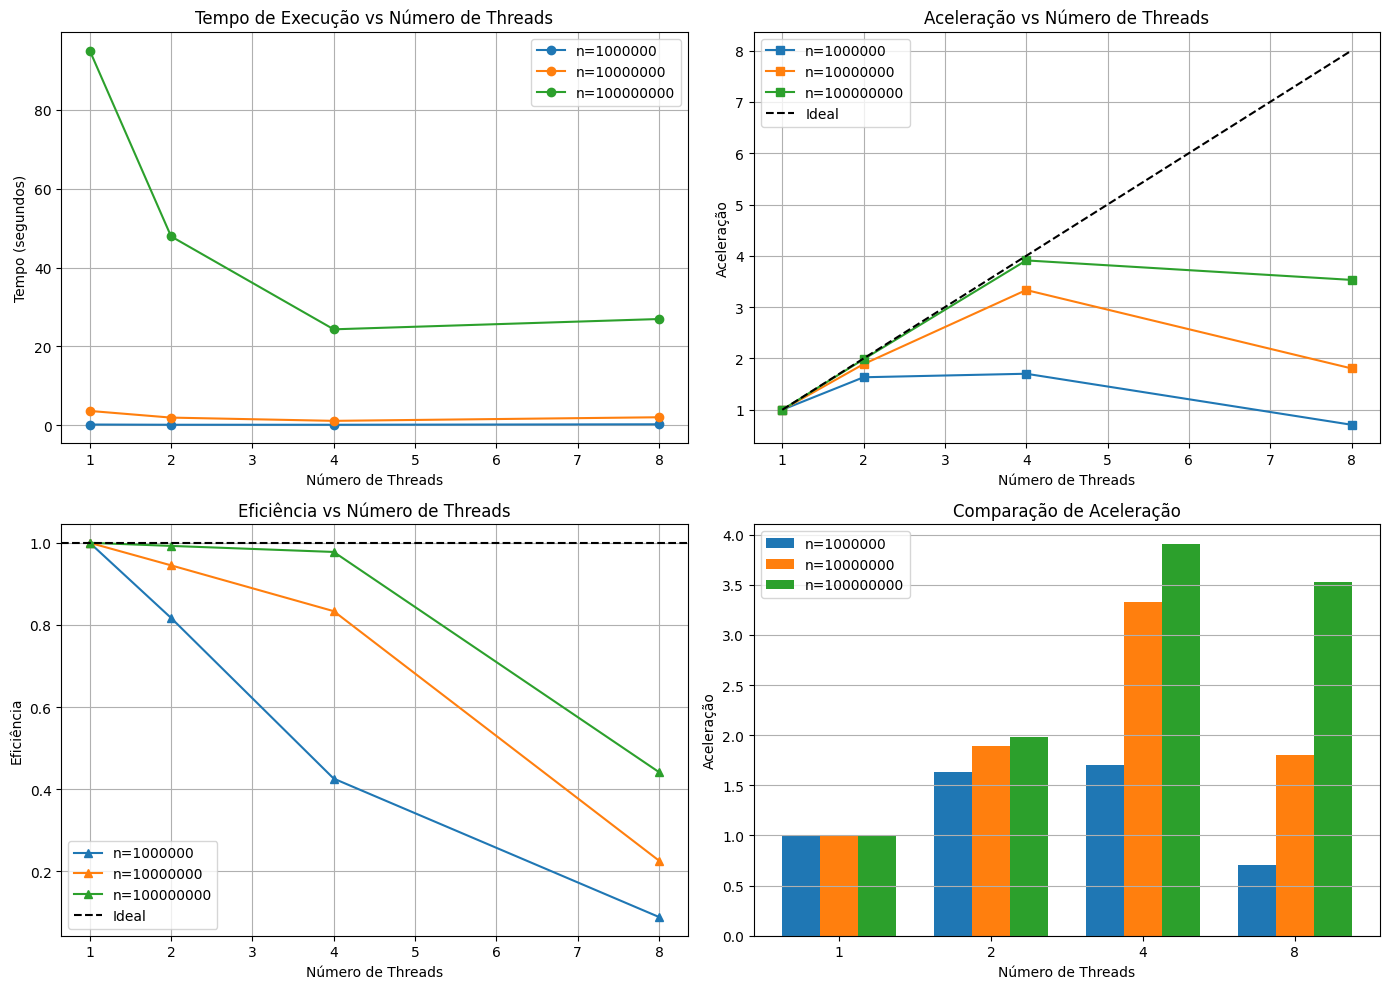

In [8]:
# Gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Tempo de Execução
for n_val in df['n'].unique():
    dados_n = df[df['n'] == n_val]
    axes[0, 0].plot(dados_n['threads'], dados_n['tempo'], marker='o', label=f'n={n_val}')
axes[0, 0].set_xlabel('Número de Threads')
axes[0, 0].set_ylabel('Tempo (segundos)')
axes[0, 0].set_title('Tempo de Execução vs Número de Threads')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Gráfico 2: Aceleração
for n_val in df['n'].unique():
    dados_n = df[df['n'] == n_val]
    axes[0, 1].plot(dados_n['threads'], dados_n['aceleracao'], marker='s', label=f'n={n_val}')
# Linha ideal
max_threads = df['threads'].max()
axes[0, 1].plot([1, max_threads], [1, max_threads], 'k--', label='Ideal')
axes[0, 1].set_xlabel('Número de Threads')
axes[0, 1].set_ylabel('Aceleração')
axes[0, 1].set_title('Aceleração vs Número de Threads')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Gráfico 3: Eficiência
for n_val in df['n'].unique():
    dados_n = df[df['n'] == n_val]
    axes[1, 0].plot(dados_n['threads'], dados_n['eficiencia'], marker='^', label=f'n={n_val}')
axes[1, 0].axhline(y=1, color='k', linestyle='--', label='Ideal')
axes[1, 0].set_xlabel('Número de Threads')
axes[1, 0].set_ylabel('Eficiência')
axes[1, 0].set_title('Eficiência vs Número de Threads')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Gráfico 4: Comparação por n
threads_vals = df['threads'].unique()
x = np.arange(len(threads_vals))
width = 0.25
for i, n_val in enumerate(df['n'].unique()):
    dados_n = df[df['n'] == n_val]
    axes[1, 1].bar(x + i*width, dados_n['aceleracao'], width, label=f'n={n_val}')
axes[1, 1].set_xlabel('Número de Threads')
axes[1, 1].set_ylabel('Aceleração')
axes[1, 1].set_title('Comparação de Aceleração')
axes[1, 1].set_xticks(x + width)
axes[1, 1].set_xticklabels(threads_vals)
axes[1, 1].legend()
axes[1, 1].grid(True, axis='y')

plt.tight_layout()
plt.savefig('analise_desempenho.png', dpi=300, bbox_inches='tight')
plt.show()

## Análise dos Resultados (Atividade 4)

### Especificações da máquina de execução
- **CPU (model name):** AMD EPYC 7B13
- **vendor_id:** AuthenticAMD
- **Arquitetura de endereçamento:** 48 bits físicos / 48 bits virtuais
- **Frequência reportada:** 2449.998 MHz
- **Cache L2 reportado por processador lógico:** 512 KB
- **Topologia observada em `/proc/cpuinfo`:**
  - 24 processadores lógicos (`processor: 0` até `processor: 23`)
  - 12 núcleos físicos (`cpu cores: 12`)
  - 2 threads por núcleo (SMT), coerente com `siblings: 24`
- **Outras informações reportadas:**
  - `TLB size: 2560 4K pages`
  - `clflush size: 64`
  - `cache_alignment: 64`
  - Ambiente virtualizado (`hypervisor` presente em `flags`)

### 1) Comportamento do tempo de execução
- Para n = 1.000.000, o tempo cai de 1 para 2 e 4 threads, mas piora com 8 threads.
- Para n = 10.000.000, há melhora forte até 4 threads; em 8 threads o tempo volta a subir.
- Para n = 100.000.000, o ganho é consistente até 4 threads; em 8 threads ainda melhora em relação a 1 thread, mas piora em relação a 4 threads.
- Em geral, o tempo não diminui indefinidamente com mais threads: após certo ponto, overhead de sincronização e escalonamento passa a dominar.

### 2) Aceleração obtida
- n = 1.000.000: speedup aproximado de 1,63 (2 threads), 1,70 (4 threads) e 0,71 (8 threads).
- n = 10.000.000: speedup aproximado de 1,89 (2), 3,33 (4) e 1,81 (8).
- n = 100.000.000: speedup aproximado de 1,98 (2), 3,91 (4) e 3,53 (8).
- O melhor ponto observado foi 4 threads, principalmente para n maiores.

### 3) Eficiência
- n = 1.000.000: eficiência ~0,82 (2), 0,43 (4), 0,09 (8).
- n = 10.000.000: eficiência ~0,95 (2), 0,83 (4), 0,23 (8).
- n = 100.000.000: eficiência ~0,99 (2), 0,98 (4), 0,44 (8).
- A eficiência cai quando o número de threads cresce além do ponto ideal, especialmente em 8 threads.

### 4) Impacto do tamanho do problema (n)
- Quanto maior n, melhor o aproveitamento do paralelismo.
- Em n pequeno, o custo de criar threads e sincronizar pesa proporcionalmente mais.
- Em n grande, esse overhead é diluído, então speedup e eficiência melhoram (principalmente até 4 threads).

### 5) Limitações observadas
- Há contenção no mutex para pegar o próximo número e para acumular resultados, o que limita escalabilidade.
- Com muitas threads, o custo de troca de contexto e concorrência por CPU pode reduzir o ganho.
- O teste de primalidade (com sqrt a cada número) é computacionalmente caro; parte do tempo é gasto nessa rotina.
- O comportamento de 8 threads sugere saturação de recursos de hardware para esse ambiente (núcleos físicos, cache e escalonador).
- Como o ambiente é virtualizado, pode haver variação de desempenho por interferência de outros workloads do host.

### Conclusão
- O paralelismo foi efetivo, principalmente para n maiores.
- Neste experimento, 4 threads apresentou o melhor equilíbrio entre tempo, speedup e eficiência.
- Aumentar para 8 threads não trouxe ganho proporcional e, em alguns casos, piorou o desempenho.

---
## Fórmulas Utilizadas

### Aceleração (Speedup):
$$A(n, t) = \frac{T_s(n, 1)}{T_p(n, t)}$$

Onde:
- $T_s(n, 1)$ é o tempo sequencial (1 thread)
- $T_p(n, t)$ é o tempo paralelo com $t$ threads

### Eficiência:
$$E(n, t) = \frac{A(n, t)}{t}$$

Onde:
- $n$ é a quantidade de elementos da sequência
- $t$ é a quantidade de threads usadas

---
## Conclusão do Laboratório

Este laboratório cobriu:
1. ✅ Corrida de dados em programas concorrentes
2. ✅ Uso de locks (mutex) para exclusão mútua
3. ✅ Violação de atomicidade e sua correção
4. ✅ Alocação dinâmica de tarefas para threads
5. ✅ Análise de desempenho (aceleração e eficiência)

**Observação:** A entrega deste laboratório deve ser feita no formulários disponível no Google Classroom.